In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json

def age_to_group(age):

    if age < 18:
        return "0-18"
    elif age <= 40:
        return "18-40"
    elif age <= 60:
        return "40-60"
    elif age <= 80:
        return "60-80"
    else:
        return "80+"

def stratify_group(row):
    # Combine demographic and label attributes into a single stratification key
    attrs = [
        str(row["gender"]).strip().upper() if pd.notna(row["gender"]) else "UNK",
        str(row["ethnicity"]).strip().upper() if pd.notna(row["ethnicity"]) else "UNK",
        str(row['age_group']).strip().upper() if pd.notna(row["age_group"]) else "UNK",
    ]

    return "_".join(attrs)

source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512

original_metadata_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv")
original_metadata_df['age_group'] = original_metadata_df['anchor_age'].apply(age_to_group)

chexpert_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-chexpert.csv")
impressions_df = pd.read_csv("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/sections/mimic_cxr_sectioned.csv")
impressions_df['study_id'] = impressions_df['study'].str.replace('s', '').astype(int)
merged_df = pd.merge(original_metadata_df, chexpert_df, on=["subject_id", "study_id"], how="inner")
# roentgen-v2 use impressions
all_df = pd.merge(impressions_df, merged_df, on="study_id", how="inner")
all_df['image'] = all_df.apply(
    lambda row: f"{raw_dir}/files/p{str(int(row['subject_id']))[:2]}/p{str(int(row['subject_id']))}/"
    f"s{int(row['study_id'])}/{row['dicom_id']}.jpg", 
    axis=1)
all_df['folder'] = all_df['subject_id'].apply(lambda x: str(x)[:2])
all_df.shape


(377024, 37)

In [2]:
# --- Filter and prepare PA_data as before ---
PA_data = all_df[all_df['ViewPosition'] == 'PA']
print('Data after excluding non-PA studies:', PA_data.shape)
PA_data = PA_data[PA_data['impression'].notna()]
print('Data after excluding studies with no impression:', PA_data.shape)
ethnicity_map = {
    'WHITE': 'White',
    'HISPANIC/LATINO': 'Hispanic', 
    'BLACK/AFRICAN AMERICAN': 'Black',
    'ASIAN': 'Asian'
}
PA_data['ethnicity'] = PA_data['ethnicity'].map(ethnicity_map)
ethnicity_to_drop = ['UNKNOWN', 'OTHER', 'UNABLE TO OBTAIN','AMERICAN INDIAN/ALASKA NATIVE']
PA_data = PA_data.dropna(subset=['ethnicity'])
PA_data['impression_length'] = PA_data['impression'].str.len()
PA_data = PA_data[~PA_data['ethnicity'].isin(ethnicity_to_drop)]
print('Data after excluding specified ethnicity values:', PA_data.shape)
PA_data['gender'] = PA_data['gender'].map({'M': 'male', 'F': 'female'})
PA_data['sentence'] = PA_data.apply(lambda row: f"{int(row['anchor_age'])} year old {row['ethnicity']} {row['gender']}. {row['impression']}", axis=1)


# Create stratification key
PA_data["stratify_key"] = PA_data.apply(stratify_group, axis=1)



Data after excluding non-PA studies: (96143, 37)
Data after excluding studies with no impression: (87056, 37)
Data after excluding specified ethnicity values: (70433, 38)


In [3]:
PA_data['gender'].unique()

array(['female', 'male'], dtype=object)

In [4]:
PA_data['ethnicity'].unique()

array(['White', 'Black', 'Asian', 'Hispanic'], dtype=object)

In [5]:
PA_data['impression'].unique()

array(['No acute cardiopulmonary abnormality.',
       'No acute cardiopulmonary process.', 'Stable chest radiograph.',
       ...,
       'Persistent small right pleural effusion.  Otherwise unremarkable. Pacemaker in\n unchanged position.',
       'Persistent small bilateral effusions.',
       'PA and lateral chest compared to a series of chest CT scans, most\n recently ___:\n \n ___ x 22 mm elliptical opacity projecting over the cardiac apex on the frontal\n view could be the lung nodule referenced.  I cannot identify it on the\n lateral.  Loss of volume in the right lung is attributable to right upper\n lobectomy and obscuration of the right heart border and anterior aspect of the\n right hemidiaphragm could be due to anatomic rearrangement stemming from\n surgery.  Upper lungs are clear.  The heart is normal size.  Thoracic aorta is\n mildly dilated and very tortuous.  There is no pleural effusion.  I see no\n explanation for decreased breath sounds in the left lower chest, excep

# Tokenizer

In [9]:
# Tokenize impressions in PA_data using Stable Diffusion's tokenizer
from transformers import AutoTokenizer
token = 'hf_TOKEN_REMOVED'
# Choose the tokenizer consistent with training code (CLIP tokenizer from SD v1-4)
model_id = "stanfordmimi/RoentGen-v2"
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        subfolder="tokenizer",
        use_fast=True,
        trust_remote_code=True,
        token=token,
    )
except Exception:
    # Fallback to default loading if subfolder is not available
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True, trust_remote_code=True, token=token)

# Ensure PA_data exists and has an 'impression' column
assert 'PA_data' in globals(), "PA_data DataFrame not found in the notebook."
assert 'impression' in PA_data.columns, "PA_data is missing the 'impression' column."

# Prepare texts (handle NaNs)
texts = PA_data['impression'].fillna("").astype(str)

# Get tokenizer max length (defaults to 77 for CLIP)
if hasattr(tokenizer, 'model_max_length'):
    max_len = tokenizer.model_max_length
else:
    max_len = 77  # fallback CLIP default

# Batch tokenize for efficiency (with truncation and max_length)
encodings = tokenizer(
    texts.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_attention_mask=True,
)

# Store tokenized outputs as list columns
PA_data['input_ids'] = encodings['input_ids']
PA_data['attention_mask'] = encodings['attention_mask']

# Check for entries that exceeded the token limit BEFORE truncation (by re-tokenizing with no truncation)
lengths = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False)) for t in texts]
PA_data['n_input_tokens'] = lengths
PA_data['truncated'] = PA_data['n_input_tokens'] > max_len

# Show stats about truncation
n_truncated = PA_data['truncated'].sum()
print(f"Number of samples truncated due to token limit ({max_len}): {n_truncated}")
if n_truncated > 0:
    print(PA_data.loc[PA_data['truncated'], ['impression', 'n_input_tokens']].head())

# Quick sanity check: show shapes/lengths of the first few entries
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Max length used:", max_len)
print("First input_ids length:", len(PA_data['input_ids'].iloc[0]) if len(PA_data) else None)


/home/vito/ibrahimm/.conda/envs/roentgen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors


Number of samples truncated due to token limit (77): 3939
                                            impression  n_input_tokens
25   Compared to chest radiographs since ___, most ...              80
335  PA and lateral chest reviewed in the absence o...             123
574  Compared to chest radiographs ___ and chest CT...              91
709  Pacemaker leads terminate in right atrium and ...              89
744  PA and lateral chest compared to ___.\n \n Sli...              79
Tokenizer vocab size: 49408
Max length used: 77
First input_ids length: 77


In [10]:
PA_data[PA_data['truncated']==True]['impression'].to_csv('long_impressions.csv')

In [15]:
PA_data[PA_data['truncated']==True]

,study,impression,findings,last_paragraph,comparison,study_id,dicom_id,subject_id,PerformedProcedureStepDescription,ViewPosition,...,Support Devices,image,folder,impression_length,sentence,stratify_key,input_ids,attention_mask,n_input_tokens,truncated
25,s50985099,"Compared to chest radiographs since ___, most ...",NaN,NaN,NaN,50985099,6ad03ed1-97ee17ee-9cf8b320-f7011003-cd93b42d,10000980,NaN,PA,...,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,397,73 year old Black female. Compared to chest ra...,FEMALE_BLACK_60-80,"[49406, 10544, 531, 10563, 7176, 24670, 1855, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",80,True
335,s53170451,PA and lateral chest reviewed in the absence o...,NaN,NaN,NaN,53170451,5f683bbb-2313fd5d-86cbea5c-705ffd10-69cb9156,10005749,NaN,PA,...,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,552,63 year old Asian female. PA and lateral chest...,FEMALE_ASIAN_60-80,"[49406, 2217, 537, 26646, 10563, 16678, 530, 5...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",123,True
574,s58861095,Compared to chest radiographs ___ and chest CT...,NaN,NaN,NaN,58861095,b8cf4fc4-4b227580-cf8d7209-2b5ed946-2d54873c,10012768,CHEST (PA AND LAT),PA,...,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,436,58 year old White male. Compared to chest radi...,MALE_WHITE_40-60,"[49406, 10544, 531, 10563, 7176, 24670, 13530,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",91,True
709,s50474111,Pacemaker leads terminate in right atrium and ...,NaN,NaN,NaN,50474111,12fd2ed8-5a501563-a86d9388-5ba1a246-2ac9104b,10015048,NaN,PA,...,1.0,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,450,81 year old Black female. Pacemaker leads term...,FEMALE_BLACK_80+,"[49406, 40600, 4836, 5335, 4766, 671, 530, 115...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",89,True
744,s54563930,PA and lateral chest compared to ___.\n \n Sli...,NaN,NaN,NaN,54563930,80ffc9e7-ce517bd3-b1160380-8fe5e817-55d58e74,10015860,Performed Desc,PA,...,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,370,53 year old White male. PA and lateral chest c...,MALE_WHITE_40-60,"[49406, 2217, 537, 26646, 10563, 10544, 531, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",79,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376894,s55120281,"In comparison with the study of ___, the right...",NaN,NaN,NaN,55120281,0420f078-3bcc3e30-6c542886-38bf1221-fed712aa,19997367,NaN,PA,...,1.0,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,413,63 year old White female. In comparison with t...,FEMALE_WHITE_60-80,"[49406, 530, 14186, 593, 518, 3123, 539, 2355,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",91,True
376898,s52570760,PA and lateral chest compared to ___:\n \n Sma...,NaN,NaN,NaN,52570760,ccf82f1d-64bd001e-a9cd560e-89283a61-27e761b7,19997367,NaN,PA,...,1.0,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,482,63 year old White female. PA and lateral chest...,FEMALE_WHITE_60-80,"[49406, 2217, 537, 26646, 10563, 10544, 531, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",107,True
376912,s50946608,"As compared to the previous radiograph, there ...",NaN,NaN,___.,50946608,b05c3652-ac78912c-939da23a-80982b03-9e8be6fc,19997367,CHEST (PA AND LAT),PA,...,1.0,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,388,63 year old White female. As compared to the p...,FEMALE_WHITE_60-80,"[49406, 601, 10544, 531, 518, 9252, 7176, 4407...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",88,True
376920,s52750463,Status post exchange of a right pectoral Port-...,NaN,NaN,___.,52750463,4b72b05f-a8397aff-4482c768-8b400c5d-bbedce4d,19997367,NaN,PA,...,1.0,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,416,63 year old White female. Status post exchange...,FEMALE_WHITE_60-80,"[49406, 6414, 1549, 6616, 539, 320, 1155, 3244...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",92,True


# openai

In [ ]:
from openai import OpenAI

client = OpenAI(
  api_key="sk-TOKEN_REMOVED"
)

task = 'Your task is to summarize this radiology report within 200 characters or less. Your response must be concise, truthful, and keep all relevant medical information.'
impression = PA_data[PA_data['truncated']==True]['impression'].iloc[0]
response = client.responses.create(
  model="gpt-5-nano",
  input=f"{task}\n\n{impression}",
  store=True,
)

print(response.output_text);

import csv




Compared to prior radiographs, edema and pneumonia have resolved. Cardiac silhouette is top-normal and improved; effusions resolved. Right hilar vessels enlarged, possibly PAH. Lateral shows LCx calcification.


In [43]:
import json

# Prepare a batch jsonl file for OpenAI /v1/chat/completions endpoint
batch_jsonl_filename = "long_impressions_openai_chat_batch.jsonl"
system_message = "You are a helpful assistant."
user_task = 'Your task is to summarize this radiology report within 200 characters or less. Your response must be concise, truthful, and keep all relevant medical information.'
model_name = "gpt-5"  # Or set to your desired model

impressions = PA_data[PA_data['truncated']==True]['impression'].reset_index(drop=True)
with open(batch_jsonl_filename, "w", encoding="utf-8") as fout:
    for idx, imp in enumerate(impressions):
        payload = {
            "custom_id": f"request-{idx + 1}",
            "method": "POST",
            "url": "/v1/chat/completions",
            "body": {
                "model": model_name,
                "messages": [
                    {"role": "system", "content": system_message},
                    {"role": "user", "content": f"{user_task}\n\n{imp}"}
                ]
            }
        }
        fout.write(json.dumps(payload) + "\n")

print(f"Wrote {len(impressions)} requests to {batch_jsonl_filename} for OpenAI batch /v1/chat/completions.")


Wrote 3939 requests to long_impressions_openai_chat_batch.jsonl for OpenAI batch /v1/chat/completions.


In [44]:
from openai import OpenAI
client = OpenAI(
  api_key="sk-TOKEN_REMOVED"
)

batch_input_file = client.files.create(
    file=open("long_impressions_openai_chat_batch.jsonl", "rb"),
    purpose="batch"
)

print(batch_input_file)

FileObject(id='file-GEpXe3D3cr8pDn9wGTnmno', bytes=3428597, created_at=1762785807, filename='long_impressions_openai_chat_batch.jsonl', object='file', purpose='batch', status='processed', expires_at=1765377807, status_details=None)


In [45]:
from openai import OpenAI

batch_input_file_id = batch_input_file.id
client.batches.create(
    input_file_id=batch_input_file_id,
    endpoint="/v1/chat/completions",
    completion_window="24h",
    metadata={
        "description": "summarize long impressions"
    }
)

Batch(id='batch_6911fa16eb008190aba6d16de9d3b598', completion_window='24h', created_at=1762785814, endpoint='/v1/chat/completions', input_file_id='file-GEpXe3D3cr8pDn9wGTnmno', object='batch', status='validating', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1762872214, failed_at=None, finalizing_at=None, in_progress_at=None, metadata={'description': 'summarize long impressions'}, model=None, output_file_id=None, request_counts=BatchRequestCounts(completed=0, failed=0, total=0), usage=BatchUsage(input_tokens=0, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=0, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=0))

In [ ]:
import time
from openai import OpenAI

batch_id = "batch_6911fa16eb008190aba6d16de9d3b598"

while True:
    batch = client.batches.retrieve(batch_id)
    print(f"Batch: {batch}")
    print(f"Status: {batch.status}")
    print(f"Batch counts: {batch.request_counts}")
    if batch.status in ["completed", "failed", "cancelled"]:
        print("Batch processing finished.")
        break
    time.sleep(60)  # wait 1 minute before checking again

Batch: Batch(id='batch_6911fa16eb008190aba6d16de9d3b598', completion_window='24h', created_at=1762785814, endpoint='/v1/chat/completions', input_file_id='file-GEpXe3D3cr8pDn9wGTnmno', object='batch', status='in_progress', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1762872214, failed_at=None, finalizing_at=None, in_progress_at=1762785878, metadata={'description': 'summarize long impressions'}, model='gpt-5-2025-08-07', output_file_id=None, request_counts=BatchRequestCounts(completed=666, failed=3134, total=3939), usage=BatchUsage(input_tokens=0, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=0, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=0))
Status: in_progress
Batch: Batch(id='batch_6911fa16eb008190aba6d16de9d3b598', completion_window='24h', created_at=1762785814, endpoint='/v1/chat/completions', input_file_id='file-GEpXe3D3cr8pDn9wGTnmno', object='batch'

KeyboardInterrupt: 

In [62]:
client.batches.list()

SyncCursorPage[Batch](data=[Batch(id='batch_6911fa16eb008190aba6d16de9d3b598', completion_window='24h', created_at=1762785814, endpoint='/v1/chat/completions', input_file_id='file-GEpXe3D3cr8pDn9wGTnmno', object='batch', status='in_progress', cancelled_at=None, cancelling_at=None, completed_at=None, error_file_id=None, errors=None, expired_at=None, expires_at=1762872214, failed_at=None, finalizing_at=None, in_progress_at=1762785878, metadata={'description': 'summarize long impressions'}, model='gpt-5-2025-08-07', output_file_id=None, request_counts=BatchRequestCounts(completed=663, failed=3105, total=3939), usage=BatchUsage(input_tokens=0, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=0, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=0)), Batch(id='batch_6911f850c2b08190adf0a756a420fd4e', completion_window='24h', created_at=1762785360, endpoint='/v1/chat/completions', input_file_id='file-6wbHup5nobWMo4hooCYjBr', object='batch', sta

In [ ]:


file_response = client.files.content("file-xyz123")
print(file_response.text)

# split data

In [12]:

from sklearn.model_selection import train_test_split

# Assign split label to each row
def assign_split(row, train_idx, val_idx, test_idx):
    if row.name in test_idx:
        return 'test'
    elif row.name in val_idx:
        return 'val'
    elif row.name in train_idx:
        return 'train'
    else:
        return 'other'

# 1. First, assign all folder 19 to test set, rest to stratified train/val split
PA_data_f10_18 = PA_data[PA_data['folder'].isin([str(i) for i in range(10, 19)])].copy()
PA_data_f19 = PA_data[PA_data['folder'] == '19'].copy()

# 2. Split folder 10-18 into train/val, stratified on stratify_key; make val size ~1300
val_size = 1300
train_idx, val_idx = train_test_split(
    PA_data_f10_18.index, 
    test_size=val_size, 
    stratify=PA_data_f10_18["stratify_key"], 
    random_state=42
)
test_idx = PA_data_f19.index

# 3. Apply split labels to all PA_data
PA_data["split"] = PA_data.apply(assign_split, axis=1, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)


In [13]:
PA_data['split'].value_counts()

split
train    62094
test      7039
val       1300
Name: count, dtype: int64

In [14]:
PA_data.to_csv("PA_data.csv", index=False)

In [19]:
PA_data

,study,impression,findings,last_paragraph,comparison,study_id,dicom_id,subject_id,PerformedProcedureStepDescription,ViewPosition,...,Pleural Other,Pneumonia,Pneumothorax,Support Devices,image,folder,impression_length,sentence,stratify_key,split
0,s53189527,No acute cardiopulmonary abnormality.,"The cardiac, mediastinal and hilar contours ar...",NaN,___,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,CHEST (PA AND LAT),PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,37,52 year old White female. No acute cardiopulmo...,FEMALE_WHITE_40-60,train
3,s50414267,No acute cardiopulmonary process.,"There is no focal consolidation, pleural effus...",NaN,None.,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,CHEST (PA AND LAT),PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,33,52 year old White female. No acute cardiopulmo...,FEMALE_WHITE_40-60,train
22,s55697293,Stable chest radiograph.,Heart size is normal. Mediastinal contours ar...,NaN,"PA and lateral chest x-ray, ___.",55697293,c50494f1-90e2bff5-e9189550-1a4562fd-6ab5204c,10000935,NaN,PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,24,52 year old Black female. Stable chest radiogr...,FEMALE_BLACK_40-60,train
25,s50985099,"Compared to chest radiographs since ___, most ...",NaN,NaN,NaN,50985099,6ad03ed1-97ee17ee-9cf8b320-f7011003-cd93b42d,10000980,NaN,PA,...,NaN,0.0,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,397,73 year old Black female. Compared to chest ra...,FEMALE_BLACK_60-80,train
27,s54935705,Mild pulmonary edema with superimposed left up...,There is mild pulmonary edema with superimpose...,NaN,___.,54935705,6ad819bb-bae74eb9-7b663e90-b8deabd7-57f8054a,10000980,CHEST (PA AND LAT),PA,...,NaN,-1.0,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,10,134,73 year old Black female. Mild pulmonary edema...,FEMALE_BLACK_60-80,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376998,s52434977,No acute cardiopulmonary abnormality.,"There is no focal consolidation, pleural effus...",NaN,"Multiple priors, most recently on ___.",52434977,4750f069-a4a2b152-61dadb2b-8e7c09a6-1c0578c2,19999068,Performed Desc,PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,37,63 year old White male. No acute cardiopulmona...,MALE_WHITE_60-80,test
377000,s50847545,No acute cardiopulmonary process.,Frontal and lateral views of the chest. No pr...,NaN,NaN,50847545,8dc9f5e1-14887015-8db378ef-2fd4441a-d45ee0f3,19999156,CHEST (PA AND LAT),PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,33,62 year old White female. No acute cardiopulmo...,FEMALE_WHITE_60-80,test
377011,s53282218,PA and lateral chest compared to a series of c...,NaN,NaN,NaN,53282218,5a5eddf4-b64e5e49-f6e9c8bc-d6409b00-015470ea,19999287,NaN,PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,1081,71 year old Black female. PA and lateral chest...,FEMALE_BLACK_60-80,test
377018,s57132437,No acute cardiothoracic process.,"The lungs are clear, and the cardiomediastinal...",NaN,None.,57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5,19999733,CHEST (PA AND LAT),PA,...,NaN,NaN,NaN,NaN,/home/vito/ibrahimm/projects/AI4Health/noteboo...,19,32,19 year old White female. No acute cardiothora...,FEMALE_WHITE_18-40,test


# write data

In [ ]:
# --- Create WebDataset from PA_data image/sentence pairs in new format ---
# --- DATA IS SPLIT BY 'split' AND EACH TAR FILE CONTAINS AT MOST 1000 SAMPLES ---

import os
import pickle
from PIL import Image
from tqdm import tqdm
import numpy as np
import tarfile
import io
import pickle
from pathlib import Path
import torch

# Directory where original images are stored
img_dir = source_dir / "files"
real_data_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data")
# Directory to write split tars
split_to_dir = {
    "train": real_data_dir / "training_data",
    "val": real_data_dir / "val_data",
    "test": real_data_dir / "test_data",
}

# Make sure split dirs exist
for d in split_to_dir.values():
    os.makedirs(d, exist_ok=True)

max_samples_per_tar = 1000

"""
!! IMPORTANT !!
Fix for torchvision.transforms.Normalize error:
- The input to torchvision transforms must be torch.float32.
- We save the images as PyTorch tensors with dtype float32 (range 0.0–1.0).
- Downstream reading/pickle.loads will recover float32 tensors, so Normalize will work.

Summary:
- Save single-channeled PyTorch tensor (float32, values in [0,1]), shape (1, H, W)
"""

split_counts = {"train": 0, "val": 0, "test": 0}
split_tar_counts = {"train": 0, "val": 0, "test": 0}
split_tar_files = {"train": None, "val": None, "test": None}
split_tar_objs = {"train": None, "val": None, "test": None}
split_tar_sample_ids = {"train": [], "val": [], "test": []}
total_counts = {"train": 0, "val": 0, "test": 0}

# Prepare an iterator grouped by split
for split in ["train", "val", "test"]:
    data_split = PA_data[PA_data["split"] == split]
    data_split = data_split.reset_index()  # So we have a unique identifier in the tar
    total_count = 0
    tar_sample_count = 0
    tar_idx = 0
    tar = None
    tar_path = None

    for idx, row in tqdm(data_split.iterrows(), total=len(data_split), desc=f"Writing split [{split}]"):
        if tar_sample_count == 0:
            # Open new tar for writing
            tar_path = split_to_dir[split] / f"{split}_{tar_idx}.tar"
            tar = tarfile.open(tar_path, "w")
        img_path = Path(row['image'])
        if img_path.exists():
            try:
                # 1. Encode image as normalized float32 torch tensor (1, H, W), values in [0, 1]
                with Image.open(img_path) as img:
                    # Convert the image to single channel ("L" mode for grayscale)
                    img = img.convert("L")
                    arr = np.array(img)
                    # arr shape will be (H, W), ensure dtype is float32 in [0,1]
                    arr = arr.astype(np.float32) / 255.0
                # Convert to shape (1, H, W) tensor (PyTorch convention for grayscale)
                arr_tensor = torch.from_numpy(arr)
                img_bytes = io.BytesIO()
                pickle.dump(arr_tensor, img_bytes)
                img_bytes.seek(0)

                # 2. Prompt metadata (UTF-8)
                prompt_bytes = row['sentence'].encode("utf-8")
                prompt_stream = io.BytesIO(prompt_bytes)

                # 3. Generate keys for inside tar; 000001, etc. (sequential within tar)
                tar_key = f"{tar_sample_count+1:06d}"

                # 4. Add .pt_image file (contains pickled float32 torch tensor)
                ptinfo = tarfile.TarInfo(f"{tar_key}.pt_image")
                ptinfo.size = img_bytes.getbuffer().nbytes
                img_bytes.seek(0)
                tar.addfile(ptinfo, img_bytes)

                # 5. Add .prompt_metadata file
                promptinfo = tarfile.TarInfo(f"{tar_key}.prompt_metadata")
                promptinfo.size = prompt_stream.getbuffer().nbytes
                prompt_stream.seek(0)
                tar.addfile(promptinfo, prompt_stream)

                tar_sample_count += 1
                total_count += 1

            except Exception as e:
                print(f"Could not process image {img_path}: {e}")
        else:
            print(f"Missing image file: {img_path}")

        # If we've reached the max samples per tar, close and write tar's _size.txt, then start a new tar
        if tar_sample_count >= max_samples_per_tar:
            tar.close()
            # Write _size.txt for this tar
            size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
            with open(size_txt_path, "w") as f:
                f.write(str(tar_sample_count) + "\n")
            print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")
            tar_sample_count = 0
            tar_idx += 1

    # After finishing split: close last tar if not already closed and not empty, and write its _size.txt
    if tar_sample_count > 0 and tar is not None:
        tar.close()
        size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
        with open(size_txt_path, "w") as f:
            f.write(str(tar_sample_count) + "\n")
        print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")

    print(f"Split {split}: total {total_count} samples in {tar_idx+1} tars.")

# End of all splits
# Start of report per split: List all tar files and their size
print("Writing complete. Tar files and sample counts per split:")
for split in ["train", "val", "test"]:
    splitdir = split_to_dir[split]
    size_files = sorted(splitdir.glob(f"{split}_*_size.txt"))
    total_in_split = 0
    for sizefile in size_files:
        try:
            with open(sizefile) as f:
                count = int(f.read().strip())
                total_in_split += count
                print(f"{sizefile.name}: {count}")
        except Exception as e:
            print(f"{sizefile.name}: Error reading: {e}")
    print(f"{split}: Total samples summed from tars: {total_in_split}")



Writing split [train]:   2%|▏         | 1021/62094 [00:04<05:10, 196.83it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_0.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_0_size.txt


Writing split [train]:   3%|▎         | 2023/62094 [00:09<04:58, 201.53it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_1.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_1_size.txt


Writing split [train]:   5%|▍         | 3012/62094 [00:14<05:24, 181.83it/s]

...

Writing split [test]:  85%|████████▌ | 6013/7039 [00:29<00:06, 158.49it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_5.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_5_size.txt


Writing split [test]: 100%|██████████| 7039/7039 [00:34<00:00, 205.75it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_6.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_6_size.txt
Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_7.tar with 39 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_7_size.txt
Split test: total 7039 samples in 8 tars.
Writing complete. Tar files and sample counts per split:
train_0_size.txt: 1000
train_10_size.txt: 1000
train_11_size.txt: 1000
train_12_size.txt: 1000
train_13_size.txt: 1000
train_14_size.txt: 1000
train_15_size.txt: 1000
train_16_size.txt: 1000
train_17_size.txt: 1000
train_18_size.txt: 1000
train_19_size.txt: 1000
tr

train_25_size.txt: 1000
train_26_size.txt: 1000
train_27_size.txt: 1000
train_28_size.txt: 1000
train_29_size.txt: 1000
train_2_size.txt: 1000
train_30_size.txt: 1000
train_31_size.txt: 1000
train_32_size.txt: 1000
train_33_size.txt: 1000
train_34_size.txt: 1000
train_35_size.txt: 1000
train_36_size.txt: 1000
train_37_size.txt: 1000
train_38_size.txt: 1000
train_39_size.txt: 1000
train_3_size.txt: 1000
train_40_size.txt: 1000
train_41_size.txt: 1000
train_42_size.txt: 1000
train_43_size.txt: 1000
train_44_size.txt: 1000
train_45_size.txt: 1000
train_46_size.txt: 1000
train_47_size.txt: 1000
train_48_size.txt: 1000
train_49_size.txt: 1000
train_4_size.txt: 1000
train_50_size.txt: 1000
train_51_size.txt: 1000
train_52_size.txt: 1000
train_53_size.txt: 1000
train_54_size.txt: 1000
train_55_size.txt: 1000
train_56_size.txt: 1000
train_57_size.txt: 1000
train_58_size.txt: 1000
train_59_size.txt: 1000
train_5_size.txt: 1000
train_60_size.txt: 1000
train_61_size.txt: 1000
train_62_size.txt: 9

In [23]:
PA_data[PA_data['study_id'] == 52331354][['Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',]]

,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
272308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN


In [29]:
PA_data.columns

Index(['study', 'impression', 'findings', 'last_paragraph', 'comparison',
       'study_id', 'dicom_id', 'subject_id',
       'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns',
       'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning',
       'ViewCodeSequence_CodeMeaning',
       'PatientOrientationCodeSequence_CodeMeaning', 'gender', 'anchor_age',
       'ethnicity', 'age_group', 'Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',
       'image', 'folder', 'impression_length', 'sentence', 'stratify_key',
       'split'],
      dtype='object')

In [ ]:
'study_id': '52331354', 'subject_id': '17222442'

# view

Prompt (000001.prompt_metadata): 71 year old White male. Right basal pleural tube has been removed or at least partially withdrawn. 
 Previous small right apical pneumothorax is smaller.  The small right pleural
 effusion is little changed.
 
 Right perihilar radiation fibrosis and small right upper lobe are unchanged. 
 Left lung is hyperinflated but grossly clear.  Previous early edema there has
 resolved and there is little residual left pleural effusion.  Heart is normal
 size.
Validation Metadata (000001.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0, 0.0], 'age': 71.0, 'age_bin': 3, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '59930557', 'subject_id': '17204052'}


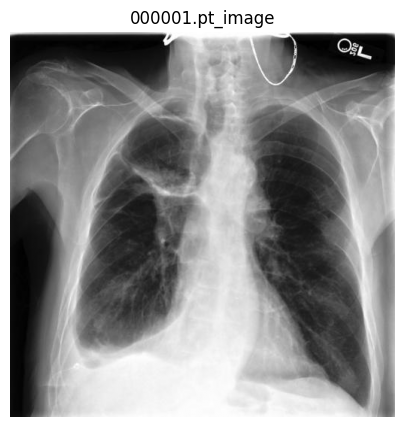

Prompt (000002.prompt_metadata): 27 year old White female. Mild pulmonary vascular congestion without frank pulmonary edema.
Validation Metadata (000002.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 'age': 27.0, 'age_bin': 1, 'sex': 'F', 'sex_idx': 1, 'race': 'WHITE', 'race_idx': 0, 'study_id': '52783129', 'subject_id': '17207245'}


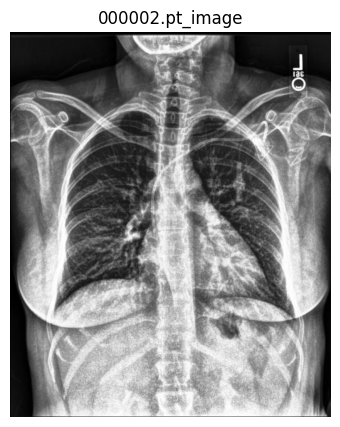

Prompt (000003.prompt_metadata): 62 year old White male. Moderate cardiomegaly.  No definite pulmonary mass is identified. 
 No evidence of acute cardiopulmonary process.
Validation Metadata (000003.validation_metadata): {'disease_labels': [-1.0, 1.0, -1.0, -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 'age': 62.0, 'age_bin': 3, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '54394902', 'subject_id': '17215130'}


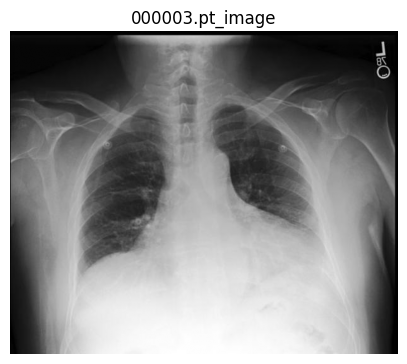

Prompt (000004.prompt_metadata): 86 year old White male. Small to moderate right pleural effusion is slightly larger, including an
 increase in the fissural component.  Some of the right lung is obscured by
 pleural effusion.  Left lung is clear.  Heart is top-normal size.  No
 pneumothorax.
Validation Metadata (000004.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 0.0, -1.0], 'age': 86.0, 'age_bin': 4, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '52331354', 'subject_id': '17222442'}


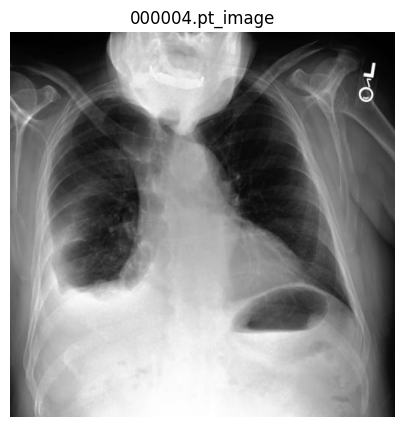

Prompt (000005.prompt_metadata): 68 year old White male. No pneumonia.
Validation Metadata (000005.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 0.0, -1.0, -1.0], 'age': 68.0, 'age_bin': 3, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '57622285', 'subject_id': '17223869'}


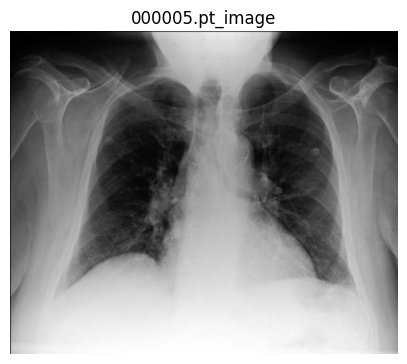

Prompt (000006.prompt_metadata): 52 year old Asian female. No acute cardiopulmonary process.  No evidence of substernal mass.
Validation Metadata (000006.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 0.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 'age': 52.0, 'age_bin': 2, 'sex': 'F', 'sex_idx': 1, 'race': 'ASIAN', 'race_idx': 2, 'study_id': '58847785', 'subject_id': '17226920'}


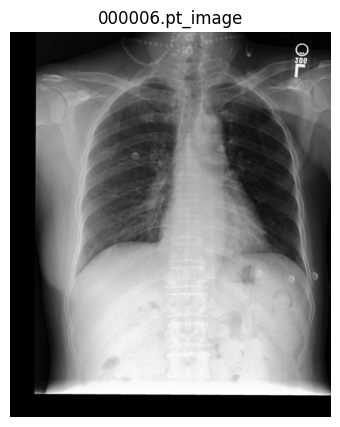

Prompt (000007.prompt_metadata): 72 year old Black female. No acute intrathoracic process.
Validation Metadata (000007.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 'age': 72.0, 'age_bin': 3, 'sex': 'F', 'sex_idx': 1, 'race': 'BLACK', 'race_idx': 1, 'study_id': '56490998', 'subject_id': '17239737'}


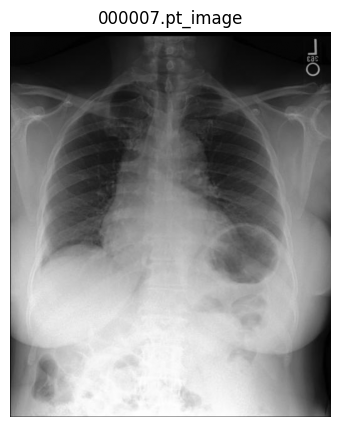

Prompt (000008.prompt_metadata): 82 year old White female. New moderately large right and stable small left pleural effusion with
 associated atelectasis.  Infection cannot be excluded.
Validation Metadata (000008.validation_metadata): {'disease_labels': [1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0], 'age': 82.0, 'age_bin': 4, 'sex': 'F', 'sex_idx': 1, 'race': 'WHITE', 'race_idx': 0, 'study_id': '57771477', 'subject_id': '17245999'}


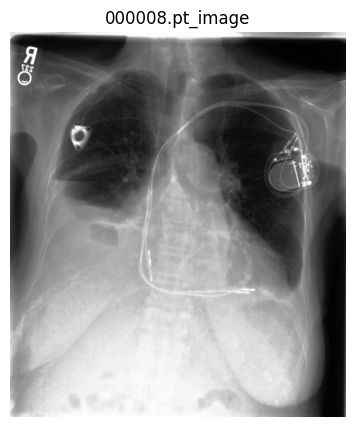

Prompt (000009.prompt_metadata): 79 year old White female. Comparison to ___.  No relevant change.  Primary complex in the right
 upper lobe.  Minimal scarring in the left upper lung.  Healed left-sided rib
 fractures.  Normal size of the cardiac silhouette.  No pulmonary edema, no
 pneumonia, no pleural effusions.
Validation Metadata (000009.validation_metadata): {'disease_labels': [-1.0, 0.0, -1.0, 0.0, -1.0, 1.0, -1.0, 1.0, -1.0, 0.0, -1.0, 0.0, -1.0, -1.0], 'age': 79.0, 'age_bin': 3, 'sex': 'F', 'sex_idx': 1, 'race': 'WHITE', 'race_idx': 0, 'study_id': '51797896', 'subject_id': '17252058'}


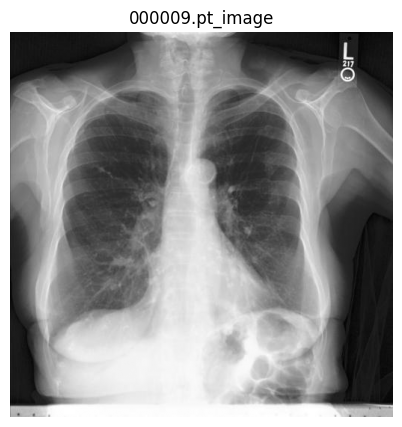

Prompt (000010.prompt_metadata): 64 year old Hispanic female. Low lung volumes, without an acute cardiac or pulmonary process.
Validation Metadata (000010.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 'age': 64.0, 'age_bin': 3, 'sex': 'F', 'sex_idx': 1, 'race': 'HISPANIC', 'race_idx': 3, 'study_id': '57397706', 'subject_id': '17258653'}


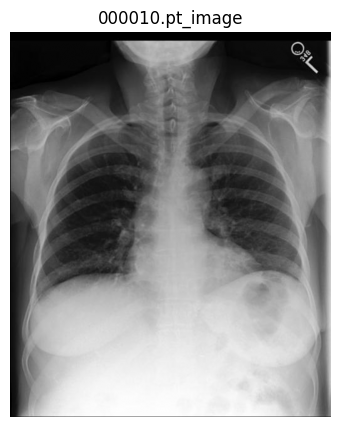

Prompt (000011.prompt_metadata): 54 year old White male. In comparison with the study of ___, there are apparent
 atelectatic changes at the left base.  The LVAD is been removed.  The pacer
 generator has been removed, as have the leads extending to the right atrium
 and right ventricle.  The wire connections from the mid subclavian level to
 the level of the carina remain in place.
 Cardiac silhouette is at the upper limits of normal in size or mildly
 enlarged.  No evidence of vascular congestion or acute focal pneumonia.
Validation Metadata (000011.validation_metadata): {'disease_labels': [1.0, 0.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 0.0, -1.0, 1.0], 'age': 54.0, 'age_bin': 2, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '52554534', 'subject_id': '17261065'}
Prompt (000012.prompt_metadata): 61 year old White male. Cardiomediastinal caliber and contour have newly return to there preoperative
 appearance. Left pleural loculation, partially fi

In [7]:
import tarfile
import pickle

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data_not_summarized/val_data/val_1.tar"

import io
from PIL import Image
import torch
import matplotlib.pyplot as plt
pics_to_show = 10
with tarfile.open(demo_tar_path, "r") as tar:
    count = 0
    for member in tar.getmembers():
        print('============================')
        # For each image, try to read its .prompt_metadata and .validation_metadata files
        # E.g., if member.name == '000001.pt_image', look for '000001.prompt_metadata' and '000001.validation_metadata'
        import json

        if member.name.endswith('.pt_image'):
            base_name = member.name.replace('.pt_image', '')
            prompt_name = base_name + '.prompt_metadata'
            valmeta_name = base_name + '.validation_metadata'

            prompt_text = None
            validation_metadata = None

            # Try to extract and read prompt_metadata
            try:
                prompt_member = tar.getmember(prompt_name)
                with tar.extractfile(prompt_member) as pf:
                    prompt_text = pf.read().decode("utf-8")
                print(f"Prompt ({prompt_name}): {prompt_text.strip()}")
            except Exception as e:
                print(f"Could not read {prompt_name}: {e}")

            # Try to extract and read validation_metadata
            try:
                valmeta_member = tar.getmember(valmeta_name)
                with tar.extractfile(valmeta_member) as vf:
                    valmeta_bytes = vf.read()
                    validation_metadata = json.loads(valmeta_bytes.decode("utf-8"))
                print(f"Validation Metadata ({valmeta_name}): {validation_metadata}")
            except Exception as e:
                print(f"Could not read {valmeta_name}: {e}")
        if "image" in member.name and count < pics_to_show:
            fileobj = tar.extractfile(member)
            data_bytes = fileobj.read()  # read bytes from ExFileObject
            img_tensor = pickle.loads(data_bytes)  # unpickle from bytes

            # If img_tensor is shape (C, H, W) and C==1, squeeze the channel or convert for display
            # If (3, H, W), convert to (H, W, 3) for RGB display
            # If (1, H, W), squeeze(0) to get (H, W)
            img_np = img_tensor.cpu().numpy()
            if img_np.ndim == 3 and img_np.shape[0] == 1:
                image = img_np.squeeze(0)  # shape (H, W)
            elif img_np.ndim == 3 and img_np.shape[0] == 3:
                # (3,H,W) -> (H,W,3)
                image = img_np.transpose(1, 2, 0)
            elif img_np.ndim == 2:
                image = img_np
            else:
                raise ValueError(f"Unsupported shape for image data: {img_np.shape}")

            plt.figure(figsize=(5,5))
            # If the image has 2 dimensions, use grayscale; if 3, let matplotlib handle it (assumes RGB)
            if image.ndim == 2:
                plt.imshow(image, cmap='gray')
            else:
                plt.imshow(image)
            plt.title(member.name)
            plt.axis('off')
            plt.show()
            count += 1


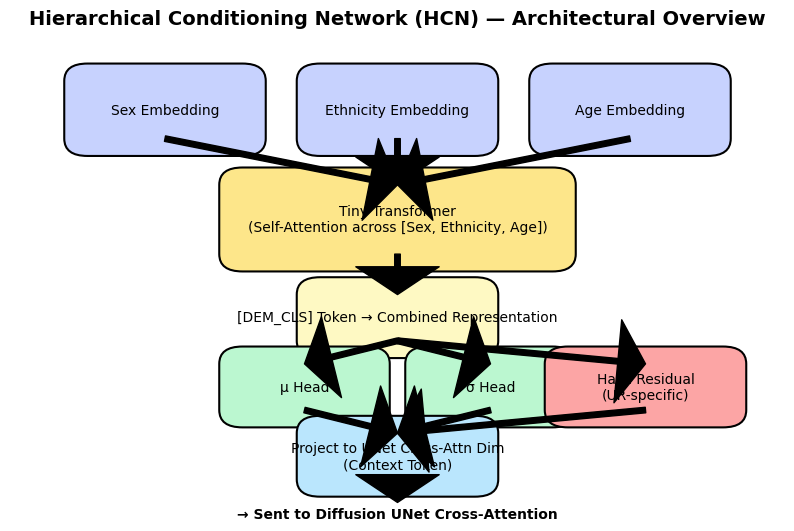

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle, ConnectionPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Helper function
def add_box(x, y, w, h, text, color='#e0e7ff', fontsize=10, style='round,pad=0.3'):
    box = FancyBboxPatch((x, y), w, h, boxstyle=style, fc=color, ec='black', lw=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, wrap=True)

# Attribute embeddings
add_box(1, 6.5, 2, 1, 'Sex Embedding', '#c7d2fe')
add_box(4, 6.5, 2, 1, 'Ethnicity Embedding', '#c7d2fe')
add_box(7, 6.5, 2, 1, 'Age Embedding', '#c7d2fe')

# Transformer block
add_box(3, 4.5, 4, 1.2, 'Tiny Transformer\n(Self-Attention across [Sex, Ethnicity, Age])', '#fde68a')

# CLS Token output
add_box(4, 3, 2, 0.8, '[DEM_CLS] Token → Combined Representation', '#fef9c3')

# Uncertainty & residual heads
add_box(3, 1.8, 1.6, 0.8, 'μ Head', '#bbf7d0')
add_box(5.4, 1.8, 1.6, 0.8, 'σ Head', '#bbf7d0')
add_box(7.2, 1.8, 2, 0.8, 'Hash Residual\n(UR-specific)', '#fca5a5')

# Projection
add_box(4, 0.6, 2, 0.8, 'Project to UNet Cross-Attn Dim\n(Context Token)', '#bae6fd')

# Arrows
arrow_style = ArrowStyle("Simple,tail_width=0.4,head_width=6,head_length=2")

# From embeddings to transformer
for x in [2, 5, 8]:
    con = ConnectionPatch((x, 6.5), (5, 5.7), 'data', 'data', arrowstyle=arrow_style, color='black')
    ax.add_patch(con)

# Transformer to CLS
ax.add_patch(ConnectionPatch((5, 4.5), (5, 3.8), 'data', 'data', arrowstyle=arrow_style, color='black'))

# CLS to heads
ax.add_patch(ConnectionPatch((5, 3), (3.8, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))
ax.add_patch(ConnectionPatch((5, 3), (6.2, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))
ax.add_patch(ConnectionPatch((5, 3), (8.2, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))

# Heads to projection
for x in [3.8, 6.2, 8.2]:
    ax.add_patch(ConnectionPatch((x, 1.8), (5, 1.4), 'data', 'data', arrowstyle=arrow_style, color='black'))

# Projection to output
ax.add_patch(ConnectionPatch((5, 0.6), (5, 0.2), 'data', 'data', arrowstyle=arrow_style, color='black'))

ax.text(5, 0, '→ Sent to Diffusion UNet Cross-Attention', ha='center', va='center', fontsize=10, fontweight='bold')
plt.title('Hierarchical Conditioning Network (HCN) — Architectural Overview', fontsize=14, fontweight='bold', pad=20)
plt.show()


In [ ]:
import tarfile

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/mimiccxr_pa_sentence_webdataset.tar"

with tarfile.open(demo_tar_path, "r") as tar:
    print("Contents of", demo_tar_path)
    for member in tar.getmembers():
        print(member.name)


In [1]:
pkl_file = '/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/output/test_run/validation_images/step_5000/gpu_0/labels.pkl'
import pickle

with open(pkl_file, 'rb') as f:
    labels = pickle.load(f)

print(labels)


{'disease': [tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1.,  0., -1., -1.]), tensor([-1., -1., -1.,  0., -1., -1., -1., -1., -1.,  0., -1.,  0., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1.,  1.]), tensor([-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]), tensor([ 1., -1., -1.,  0.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  0., -1.]), tensor([-1.,  1., -1., -1.,  0., -1., -1., -1., -1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1.,

In [3]:
import torch
radnet = torch.hub.load("Warvito/radimagenet-models", model="radimagenet_resnet50", trust_repo=True, verbose=True)


Using cache found in /home/vito/ibrahimm/.cache/torch/hub/Warvito_radimagenet-models_main


ConnectionError: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))